In [6]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 51.4 MB/s eta 0:00:00


# Simple two level system as a single photon emitter


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

In [8]:
# 1. CONFIGURATION
def get_parameters(gamma, ntraj):
    params = {
        'gamma': gamma,        # Spontaneous emission rate
        'Omega': 2.0 * gamma,  # Rabi frequency
        'Delta': 0.0 * gamma,  # Detuning

        'tau_range': np.linspace(0, 10.0/gamma, 200),

        'mc_time': np.linspace(0, 1000/gamma, 10000), # Long trace for stats
        'ntraj': ntraj  # Single experimental run
    }
    return params

In [9]:
# 2. MODEL BUILDER
def build_system(params):
    sm = sigmam()      # Lowering operator
    sp = sigmap()      # Raising operator
    n_op = sm.dag() * sm  # Number operator

    H = params['Delta'] * n_op + (params['Omega'] / 2.0) * (sp + sm)

    return {
        'H': H,
        'sm': sm,
        'sp': sp,
        'n_op': n_op
    }

In [10]:
# 3. THEORETICAL SOLVER (Master Equation)
def calculate_theoretical_g2(system, params):
    """
    Calculates g2(tau) using the Master Equation and Quantum Regression Theorem
    logic (Conditional Evolution).
    """
    H = system['H']
    sm = system['sm']
    n_op = system['n_op']
    gamma = params['gamma']
    taus = params['tau_range']

    # Standard collapse operator for the atom
    c_ops = [np.sqrt(gamma) * sm]

    # A. Find Steady State
    rho_ss = steadystate(H, c_ops)
    n_ss = expect(n_op, rho_ss)

    # B. Prepare Conditioned State (Post-detection state)
    #    Project atom to ground state: rho -> sm * rho * sm_dag
    rho_conditioned = sm * rho_ss * sm.dag()
    rho_conditioned = rho_conditioned / rho_conditioned.tr() # Normalize

    # C. Evolve system to see recovery
    result = mesolve(H, rho_conditioned, taus, c_ops, [n_op])

    # D. Calculate g2: <n(tau)>_cond / <n>_ss
    g2 = result.expect[0] / n_ss

    return taus, g2

In [11]:
# 4. EXPERIMENTAL SOLVER (Monte Carlo)
def run_monte_carlo_experiment(system, params):
    """
    Simulates a 'Virtual Experiment' generating discrete detector clicks.
    Models a 50:50 Beam Splitter HBT setup.
    """
    H = system['H']
    sm = system['sm']
    gamma = params['gamma']
    tlist = params['mc_time']

    # Channel 1 (Detector 1) and Channel 2 (Detector 2)
    c_ops_hbt = [np.sqrt(0.5 * gamma) * sm,
                 np.sqrt(0.5 * gamma) * sm]

    # Run Simulation
    result = mcsolve(H, basis(2,0), tlist, c_ops_hbt, [], ntraj=params['ntraj'])

    # Extract Data
    col_times = result.col_times[0]
    col_which = result.col_which[0]

    # Sort clicks by detector
    t1 = np.array([col_times[i] for i in range(len(col_times)) if col_which[i] == 0])
    t2 = np.array([col_times[i] for i in range(len(col_times)) if col_which[i] == 1])

    return t1, t2

In [12]:
# 5. DATA ANALYSIS
def compute_coincidences(t1, t2, params):
    """
    Calculates time delays (tau = t2 - t1) between clicks to build a histogram.
    """
    delays = []
    # Maximum delay to look for (matches the theory plot range)
    max_tau = params['tau_range'].max()

    # Cross-correlate t1 and t2
    for x in t1:
        nearby_clicks = t2[(t2 > x - max_tau) & (t2 < x + max_tau)]
        for y in nearby_clicks:
            delays.append(y - x)

    return delays

In [13]:
def plot_results(theory_data, exp_data, params):
    """Generates the final comparison plot."""
    tau_theory, g2_theory = theory_data
    t1, t2, delays = exp_data
    gamma = params['gamma']

    fig = plt.figure(figsize=(12, 10))

    # --- Plot 1: Click Stream (Visual Proof) ---
    ax1 = fig.add_subplot(2, 1, 1)
    ax1.set_xlim(0, 40) # Zoom in
    ax1.eventplot(t1, lineoffsets=1, linelengths=0.8, colors='r', label='Detector 1')
    ax1.eventplot(t2, lineoffsets=-1, linelengths=0.8, colors='b', label='Detector 2')
    ax1.set_yticks([-1, 1])
    ax1.set_yticklabels(['Det 2', 'Det 1'])
    ax1.set_xlabel(r'Time ($1/\gamma$)')
    ax1.set_title('Raw Detector Clicks (Monte Carlo Stream)')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right')

    # --- Plot 2: Histogram vs Theory ---
    ax2 = fig.add_subplot(2, 1, 2)

    # Plot Histogram (Experiment)
    max_tau = tau_theory.max()
    n, bins, _ = ax2.hist(delays, bins=60, range=(-max_tau, max_tau),
                          density=True, color='purple', alpha=0.5,
                          label='Exp. Coincidences')

    # Plot Theory (Twin Axis)
    ax3 = ax2.twinx()
    ax3.plot(tau_theory, g2_theory, 'b-', lw=3, label='Theory')
    ax3.plot(-tau_theory, g2_theory, 'b-', lw=3) # Mirror for negative side

    # Formatting
    ax2.set_xlabel(r'Time Delay $\tau$')
    ax2.set_ylabel('Coincidence Density')
    ax3.set_ylabel(r'$g^{(2)}(\tau)$')
    ax3.set_ylim(0, max(g2_theory)*1.1)

    ax2.set_title('Verification: Experiment (Bars) matches Theory (Line)')
    ax2.axvline(0, color='k', linestyle='--', alpha=0.5)

    # Legend combining both axes
    lines_1, labels_1 = ax2.get_legend_handles_labels()
    lines_2, labels_2 = ax3.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

    plt.tight_layout()
    plt.show()

In [14]:
def main(gamma = 1, ntraj = 1):
    params = get_parameters(gamma, ntraj)
    system = build_system(params)

    print("Calculating Theory...")
    tau_theory, g2_theory = calculate_theoretical_g2(system, params)

    print("Running Experiment...")
    t1, t2 = run_monte_carlo_experiment(system, params)
    print(f"  -> Collected {len(t1)} clicks on Det 1, {len(t2)} on Det 2")

    print("Processing Data...")
    delays = compute_coincidences(t1, t2, params)

    plot_results((tau_theory, g2_theory), (t1, t2, delays), params)

Calculating Theory...
Running Experiment...
100.0%. Run time:   0.00s. Est. time left: 00:00:00:00


/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


Total run time:   0.64s
  -> Collected 214 clicks on Det 1, 256 on Det 2
Processing Data...


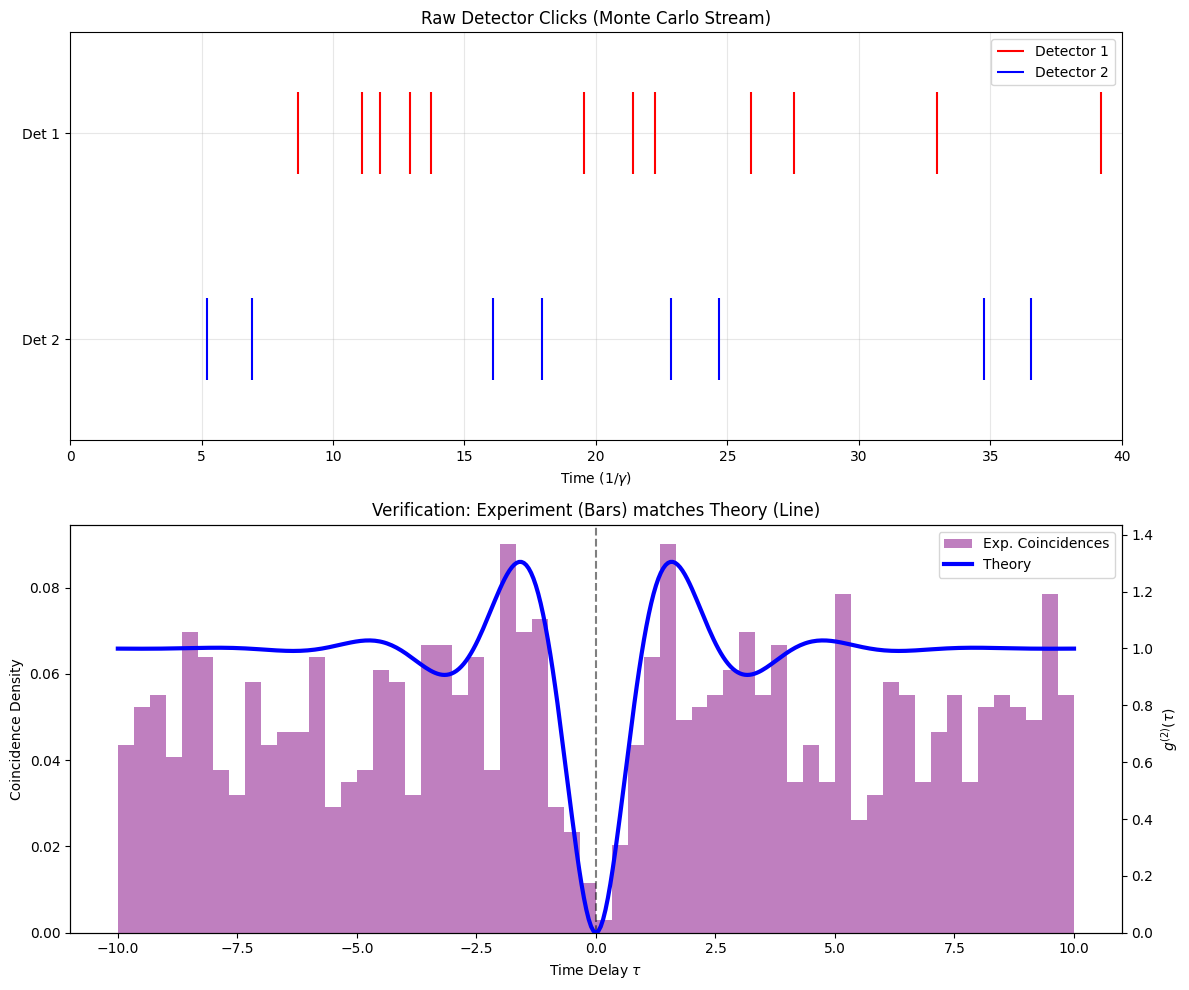

In [15]:
if __name__ == "__main__":
    main()

# Three level system as a single photon emitter

In [27]:
def get_blinking_parameters(gamma = 1, ntraj = 1):
    params = {
        'gamma': gamma,       # Radiative decay rate
        'Omega': 2.0 * gamma,
        'Delta': 0.0 * gamma,

        # Rate of falling into the dark state (switching OFF)
        'gamma_off': 0.05 * gamma,
        # Rate of recovering from dark state (switching ON)
        'gamma_on': 0.02 * gamma,

        # Timescales
        'tau_range': np.linspace(0, 50.0/gamma, 300),
        'mc_time': np.linspace(0, 10000/gamma, 100000), # Very long trace
        'ntraj': ntraj
    }
    return params

In [28]:
def build_blinking_system(params):
    g = basis(3, 0)
    e = basis(3, 1)
    s = basis(3, 2)

    # Operators
    #    Emits only when transitioning e -> g
    sm_emit = g * e.dag()  # |0><1|

    #    Laser only couples g <-> e. It cannot see the dark state s.
    H_drive = (params['Omega'] / 2.0) * (e * g.dag() + g * e.dag())

    #    Energy of excited state relative to ground
    H_det = params['Delta'] * (e * e.dag())

    H = H_det + H_drive

    # Collapse Operators (The Environment)
    c_ops = []

    # A. Radiative Decay (Photon Emission)
    c_ops.append(np.sqrt(params['gamma']) * sm_emit)

    # B. Blinking OFF (Trapping: e -> s)
    #    Rate at which the active dot gets stuck in a dark state
    op_off = s * e.dag() # |2><1|
    c_ops.append(np.sqrt(params['gamma_off']) * op_off)

    # C. Blinking ON (Recovery: s -> g)
    #    Rate at which the dot recovers to ground state
    op_on = g * s.dag() # |0><2|
    c_ops.append(np.sqrt(params['gamma_on']) * op_on)

    return {
        'H': H,
        'sm_emit': sm_emit, # We only detect photons from this operator
        'n_emit': sm_emit.dag() * sm_emit,
        'c_ops': c_ops
    }

In [29]:
def calculate_blinking_theory(system, params):
    H = system['H']
    sm = system['sm_emit']
    n_op = system['n_emit']
    c_ops = system['c_ops']
    taus = params['tau_range']

    # Steady State
    rho_ss = steadystate(H, c_ops)
    n_ss = expect(n_op, rho_ss)

    # Conditional Evolution (g2)
    rho_cond = sm * rho_ss * sm.dag()
    rho_cond = rho_cond / rho_cond.tr()

    # 3. Evolve
    result = mesolve(H, rho_cond, taus, c_ops, [n_op])
    g2 = result.expect[0] / n_ss

    return taus, g2


In [30]:
def run_blinking_experiment(system, params):
    H = system['H']
    sm = system['sm_emit']
    tlist = params['mc_time']
    gamma = params['gamma']

    c_ops_hbt = [
        np.sqrt(0.5 * gamma) * sm,     # Detector 1
        np.sqrt(0.5 * gamma) * sm,     # Detector 2
        system['c_ops'][1], # blinking off
        system['c_ops'][2]  # blinking on
    ]

    # Run
    result = mcsolve(H, basis(3,0), tlist, c_ops_hbt, [], ntraj=1)

    col_times = result.col_times[0]
    col_which = result.col_which[0]

    t1 = [col_times[i] for i in range(len(col_times)) if col_which[i] == 0]
    t2 = [col_times[i] for i in range(len(col_times)) if col_which[i] == 1]

    return np.array(t1), np.array(t2)

In [33]:
def plot_blinking_results(theory, experiment, params):
    tau, g2_theory = theory
    t1, t2 = experiment

    fig = plt.figure(figsize=(12, 10))

    ax1 = fig.add_subplot(2, 1, 1)
    ax1.set_xlim(0, 500)
    ax1.vlines(t1, 0, 1, color='r', alpha=0.5, label='Det 1')
    ax1.vlines(t2, -1, 0, color='b', alpha=0.5, label='Det 2')
    ax1.set_yticks([])
    ax1.set_xlabel(r'Time ($1/\gamma$)')
    ax1.set_title('Blinking Trace: Telegraph Noise', fontsize=14)

    ax2 = fig.add_subplot(2, 1, 2)

    delays = []
    max_tau = tau.max()
    for x in t1:
        # Optimization: Only look for clicks within the max_tau window
        nearby = t2[(t2 > x - max_tau) & (t2 < x + max_tau)]
        for y in nearby:
            delays.append(y - x)

    bins = 100
    counts, bin_edges = np.histogram(delays, bins=bins, range=(-max_tau, max_tau))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    tail_counts = np.concatenate([counts[:10], counts[-10:]])
    norm_factor = np.mean(tail_counts)

    if norm_factor == 0: norm_factor = 1

    g2_exp = counts / norm_factor

    width = (bin_edges[1] - bin_edges[0])
    ax2.bar(bin_centers, g2_exp, width=width, color='purple', alpha=0.4, label='Experiment (Normalized)')

    ax2.plot(tau, g2_theory, 'b-', lw=2, label='Theory')
    ax2.plot(-tau, g2_theory, 'b-', lw=2)

    ax2.set_xlabel(r'Time Delay $\tau$')
    ax2.set_ylabel(r'$g^{(2)}(\tau)$')
    ax2.set_title(r'Verification: Experiment matches Theory')
    ax2.legend()
    ax2.grid(True, alpha=0.2)

    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    axins = inset_axes(ax2, width="30%", height="40%", loc='upper right')
    axins.bar(bin_centers, g2_exp, width=width, color='purple', alpha=0.4)
    axins.plot(tau, g2_theory, 'b-')
    axins.plot(-tau, g2_theory, 'b-')
    axins.set_xlim(-2, 2) # Zoom in very close to zero
    axins.set_ylim(0, 1.5)
    axins.set_yticks([0, 1])

    plt.tight_layout()
    plt.show()

100.0%. Run time:   0.00s. Est. time left: 00:00:00:00


/usr/local/lib/python3.12/dist-packages/qutip/solver/solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


Total run time:   5.02s


/tmp/ipython-input-1806552464.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


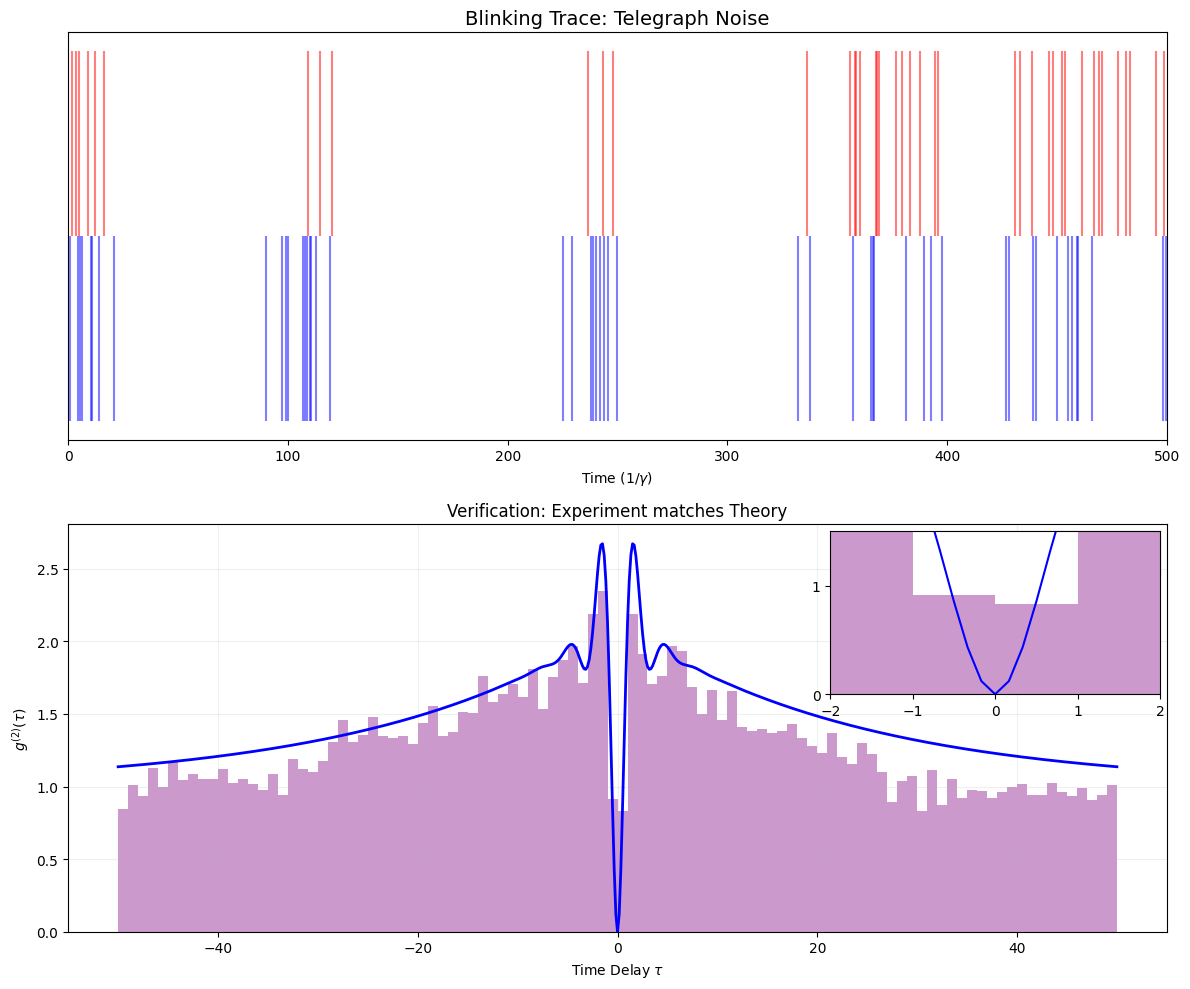

In [34]:

if __name__ == "__main__":
    p = get_blinking_parameters()
    s = build_blinking_system(p)
    th = calculate_blinking_theory(s, p)
    ex = run_blinking_experiment(s, p)
    plot_blinking_results(th, ex, p)